[Previous: GoF 5: Behavioral Patterns, Part 2](05_Behavioral_Part_2.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 7: Patterns in Python](07_Patterns_in_Python.ipynb)

# GoF 6: Behavioral Patterns, Part 3

**Learning objectives.** After this module you can:

* fix an algorithm's skeleton with Template Method and let subclasses fill in steps;
* add operations to a family of node classes with Visitor, and explain double dispatch;
* build a small Interpreter: a grammar as classes, a parser that produces the tree, and evaluation by walking it.

## 1. Template Method

**Problem.** Exporting data to CSV, JSON or XML follows the same steps (fetch, filter, format, write) and only some steps differ. Copying the skeleton into each exporter duplicates the parts that are the same.

**Structure.** The base class implements the skeleton as a method that calls step methods in order. Subclasses override only the steps that differ. Optional **hooks** have a default that does nothing.

CsvExporter -> 20 chars written
  json size check: 83 chars
JsonExporter -> 83 chars written


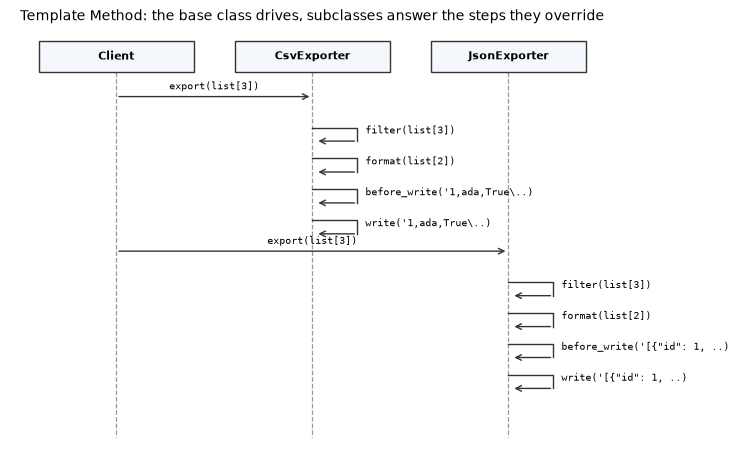

In [1]:
from dplab import class_diagram, tree_diagram, traced, trace

@traced
class Exporter:
    def export(self, rows):                        # the template method: fixed order, in the base class
        rows = self.filter(rows)
        text = self.format(rows)
        self.before_write(text)                    # hook: does nothing unless overridden
        return self.write(text)

    def filter(self, rows):  return [r for r in rows if r.get("active", True)]
    def format(self, rows):  raise NotImplementedError
    def before_write(self, text): pass
    def write(self, text):   return f"{len(text)} chars written"

@traced
class CsvExporter(Exporter):
    def format(self, rows):
        return "\n".join(",".join(str(v) for v in r.values()) for r in rows)

@traced
class JsonExporter(Exporter):
    def format(self, rows):
        import json
        return json.dumps(rows)
    def before_write(self, text):                  # uses the hook
        print("  json size check:", len(text), "chars")

rows = [{"id": 1, "name": "ada", "active": True}, {"id": 2, "name": "bob", "active": False}, {"id": 3, "name": "cy", "active": True}]
with trace() as t:
    for exporter in (CsvExporter(), JsonExporter()):
        print(type(exporter).__name__, "->", exporter.export(rows))
t.diagram(title="Template Method: the base class drives, subclasses answer the steps they override")

> **What to notice.** Every call in the diagram goes to the subclass instance, but most of them land in code written in the base class.
> This is the one pattern that relies on inheritance rather than composition; keep the skeleton short or it becomes hard to follow.

## 2. Visitor

**Problem.** You have a fixed set of node classes (numbers, additions, multiplications) and keep needing new operations over them: evaluate, print, count nodes, type-check.
Adding a method to every class for every operation scatters each operation across the hierarchy.

**Structure.** Each operation is a Visitor class with one `visit_X` method per node type. Each node has `accept(visitor)` that calls the right `visit_X`.
That call is **double dispatch**: the node type picks the method, the visitor object picks the operation.

Evaluator    20
Printer      (2 + 3) * 4
NodeCounter  5


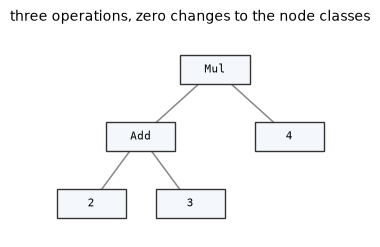

In [2]:
class Num:
    def __init__(self, value): self.value = value
    def accept(self, visitor): return visitor.visit_num(self)

class Add:
    def __init__(self, left, right): self.left, self.right = left, right
    def accept(self, visitor): return visitor.visit_add(self)

class Mul:
    def __init__(self, left, right): self.left, self.right = left, right
    def accept(self, visitor): return visitor.visit_mul(self)

class Evaluator:
    def visit_num(self, n): return n.value
    def visit_add(self, n): return n.left.accept(self) + n.right.accept(self)
    def visit_mul(self, n): return n.left.accept(self) * n.right.accept(self)

class Printer:
    def visit_num(self, n): return str(n.value)
    def visit_add(self, n): return f"({n.left.accept(self)} + {n.right.accept(self)})"
    def visit_mul(self, n): return f"{n.left.accept(self)} * {n.right.accept(self)}"

class NodeCounter:
    def visit_num(self, n): return 1
    def visit_add(self, n): return 1 + n.left.accept(self) + n.right.accept(self)
    def visit_mul(self, n): return 1 + n.left.accept(self) + n.right.accept(self)

expr = Mul(Add(Num(2), Num(3)), Num(4))
for visitor in (Evaluator(), Printer(), NodeCounter()):
    print(f"{type(visitor).__name__:<12}", expr.accept(visitor))
tree_diagram(expr, lambda n: [n.left, n.right] if not isinstance(n, Num) else [],
             lambda n: str(n.value) if isinstance(n, Num) else type(n).__name__, title="three operations, zero changes to the node classes")

In [3]:
# Python alternative: functools.singledispatch dispatches on the node type without accept() methods.
from functools import singledispatch

@singledispatch
def evaluate(node):
    raise TypeError(type(node))

@evaluate.register
def _(node: Num): return node.value

@evaluate.register
def _(node: Add): return evaluate(node.left) + evaluate(node.right)

@evaluate.register
def _(node: Mul): return evaluate(node.left) * evaluate(node.right)

print("singledispatch evaluate:", evaluate(expr))

singledispatch evaluate: 20


> **What to notice.** Visitor makes adding an *operation* cheap and adding a *node type* expensive (every visitor needs a new method). Choose it when the node set is stable.

## 3. Interpreter

**Problem.** Users need to write small expressions (formulas, filters, rules) and the program must evaluate them.

**Structure.** One class per grammar rule with an `interpret()` method; the sentence is a tree of those objects (a Composite); a parser builds the tree from text.
The grammar below is the classic arithmetic one:

```
expr   := term (('+' | '-') term)*
term   := factor (('*' | '/') factor)*
factor := number | '(' expr ')' | '-' factor
```

1 + 2 * 3      = 7
(1 + 2) * 3    = 9
-4 + 10 / 4    = -1.5


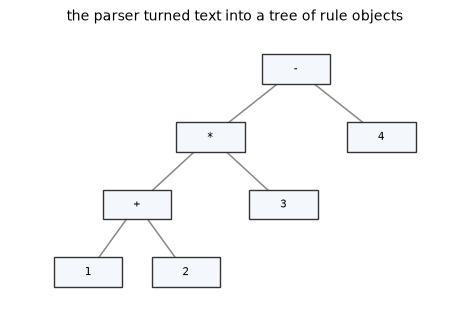

In [4]:
class Number:
    def __init__(self, v): self.v = v
    def interpret(self): return self.v

class BinOp:
    def __init__(self, op, left, right): self.op, self.left, self.right = op, left, right
    def interpret(self):
        a, b = self.left.interpret(), self.right.interpret()
        return {"+": a + b, "-": a - b, "*": a * b, "/": a / b}[self.op]

def tokenize(text):
    tokens, i = [], 0
    while i < len(text):
        ch = text[i]
        if ch.isspace(): i += 1
        elif ch.isdigit() or ch == ".":
            j = i
            while j < len(text) and (text[j].isdigit() or text[j] == "."): j += 1
            tokens.append(("num", float(text[i:j]))); i = j
        elif ch in "+-*/()": tokens.append(("op", ch)); i += 1
        else: raise ValueError(f"bad character {ch!r}")
    return tokens

class Parser:                                  # recursive descent: one method per grammar rule
    def __init__(self, text): self.tokens, self.pos = tokenize(text), 0
    def peek(self): return self.tokens[self.pos] if self.pos < len(self.tokens) else (None, None)
    def take(self): tok = self.peek(); self.pos += 1; return tok

    def expr(self):
        node = self.term()
        while self.peek() in (("op", "+"), ("op", "-")):
            node = BinOp(self.take()[1], node, self.term())
        return node

    def term(self):
        node = self.factor()
        while self.peek() in (("op", "*"), ("op", "/")):
            node = BinOp(self.take()[1], node, self.factor())
        return node

    def factor(self):
        kind, value = self.take()
        if kind == "num": return Number(value)
        if (kind, value) == ("op", "("):
            node = self.expr(); self.take(); return node
        if (kind, value) == ("op", "-"): return BinOp("-", Number(0), self.factor())
        raise ValueError("expected a number or '('")

for text in ["1 + 2 * 3", "(1 + 2) * 3", "-4 + 10 / 4"]:
    tree = Parser(text).expr()
    print(f"{text:<14} = {tree.interpret():g}")
tree_diagram(Parser("(1 + 2) * 3 - 4").expr(), lambda n: [n.left, n.right] if isinstance(n, BinOp) else [],
             lambda n: n.op if isinstance(n, BinOp) else f"{n.v:g}", title="the parser turned text into a tree of rule objects")

### Lab: Interpreter Lab

Type any expression. The tree is redrawn, `interpret()` evaluates it, and a Visitor prints it in prefix notation. Try an unbalanced bracket to see the parser complain.

Interpreter Lab (static preview). Run this cell in JupyterLab for the interactive version.


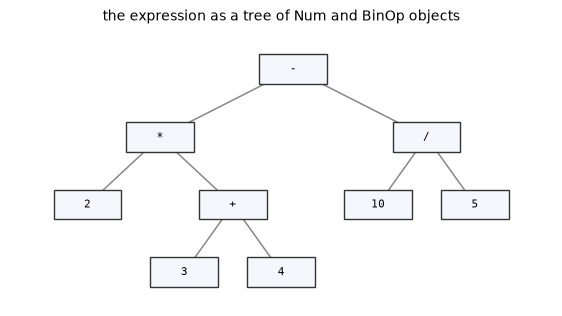

In [5]:
from dplab import interpreter_lab

interpreter_lab()

## Try it yourself

**Exercise 1.** Add an `XmlExporter` to the Template Method example that overrides `format` and also `filter` (keep inactive rows too).

**Exercise 2.** Add a `Neg` node to the Visitor example and update all three visitors. Then add a `Depth` visitor. Which change was more work, and why?

**Exercise 3.** Extend the interpreter grammar with `^` for exponentiation, binding tighter than `*`. (Add a `power` rule between `term` and `factor`.)

**Exercise 4 (challenge).** Add variables to the interpreter: `x * 2` with an environment dict passed to `interpret(env)`.

<details><summary>Solutions</summary>

```python
# Exercise 1
class XmlExporter(Exporter):
    def filter(self, rows): return rows
    def format(self, rows): return "".join(f"<row id='{r['id']}' name='{r['name']}'/>" for r in rows)

# Exercise 2: Neg touches every visitor (3 edits); Depth is one new class. Visitor trades easy operations for hard node types.

# Exercise 3
def power(self):
    node = self.factor()
    if self.peek() == ("op", "^"):
        self.take(); node = BinOp("^", node, self.power())     # right-associative
    return node
# add "^" to tokenize's operator characters, to BinOp.interpret ({"^": a ** b}), and make term() call self.power() instead of self.factor().

# Exercise 4
class Var:
    def __init__(self, name): self.name = name
    def interpret(self, env): return env[self.name]
# give every interpret() an env parameter and let the tokenizer emit ("var", name) for letters.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [6]:
from dplab import quiz

quiz(6)

Checkpoint quiz, Module 6 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Template Method
    a) fixes the skeleton of an algorithm in a base class and lets subclasses fill in steps
    b) copies templates
    c) wraps objects
    d) queues commands

Q2. Visitor lets you
    a) add new element classes easily
    b) add new operations over a fixed set of element classes without changing them
    c) share elements
    d) undo operations

Q3. The trick that makes Visitor work is
    a) single dispatch
    b) double dispatch: accept() calls visit_X() chosen by both element and visitor
    c) reflection
    d) global state

Q4. Interpreter represents
    a) a user interface
    b) grammar rules as classes and evaluates sentences by walking the tree
    c) a network protocol
    d) a queue


## Key takeaways

* Template Method: the skeleton lives in the base class; subclasses override steps and hooks. The one inheritance-based pattern here.
* Visitor: operations as classes, `accept` as the double-dispatch hinge; cheap new operations, expensive new node types. `singledispatch` is the Python shortcut.
* Interpreter: grammar rules as classes, a recursive-descent parser, evaluation by tree walk. Composite and Visitor are its natural partners.

**Next:** which of all this Python already does for you. [GoF 7](07_Patterns_in_Python.ipynb).

[Previous: GoF 5: Behavioral Patterns, Part 2](05_Behavioral_Part_2.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 7: Patterns in Python](07_Patterns_in_Python.ipynb)